In [8]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [ ]:
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = keras.Sequential([

    keras.layers.Dense(64, activation='relu', input_shape=(13,)),

    keras.layers.Dense(32, activation='relu'),

    keras.layers.Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.5115 - mae: 1.5527
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1156 - mae: 1.4463
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0738 - mae: 1.4609
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0582 - mae: 1.4371
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0228 - mae: 1.4276
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9350 - mae: 1.3902
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1331 - mae: 1.4928
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9549 - mae: 1.4418
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9038 - mae: 1.4297
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.8482 - mae: 1.4122
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7515 - mae: 1.3719
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.8276 - mae: 1.3989
Epoch 13/100
51/51 ━━━━━━━━━━━━━━━━━━

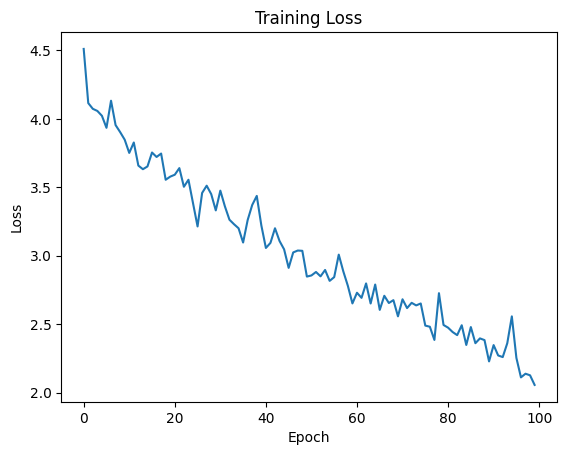

In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8
)


loss, mae = model.evaluate(X_test, y_test)

print("\nMean Absolute Error:", mae)



plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
predictions = model.predict(X_test)

print("\nSample Predicted Prices:\n")

for i in range(5):
    print("Predicted:", predictions[i][0],
          " Actual:", y_test[i])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Sample Predicted Prices:

Predicted: 6.6328526  Actual: 7.2
Predicted: 18.598995  Actual: 18.8
Predicted: 20.644066  Actual: 19.0
Predicted: 36.013298  Actual: 27.0
Predicted: 24.69023  Actual: 22.2


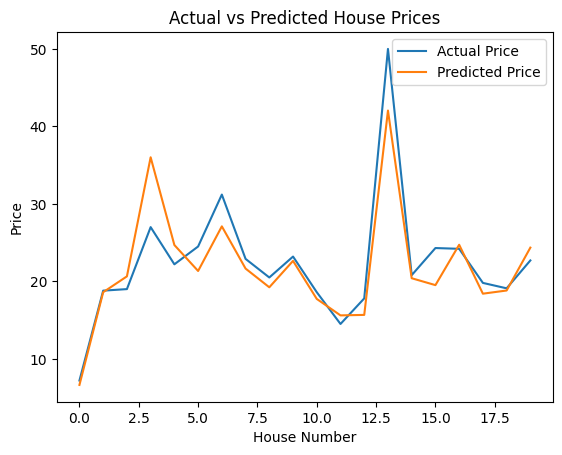

In [9]:
plt.plot(y_test[:20], label='Actual Price')
plt.plot(predictions[:20], label='Predicted Price')

plt.title("Actual vs Predicted House Prices")
plt.xlabel("House Number")
plt.ylabel("Price")
plt.legend()
plt.show()